# P2 - Regression Modeling: Predicting Movie Profit

**Course:** YZM2011 - Introduction to Machine Learning  
**Dataset:** IMDb Top 5000 Movies + TMDB financial data  
**Target:** `profit = revenues - budget`

This notebook builds on P1 by using the cleaned movie dataset to train and compare regression models for movie profit prediction.

# 1. Recap & Motivation

P1 studied the IMDb Top 5000 movies by combining IMDb ranking, rating, vote, runtime, genre, director, and writer data with TMDB budget and box-office revenue data. The overall project asks what factors drive movie financial success and audience reception.

For P2, the regression target is **`profit`**, defined as **box-office revenue minus production budget**, measured in USD. This target represents the direct financial surplus or loss associated with each movie in the merged dataset.

P1 showed that financial variables are heavily right-skewed and contain blockbuster outliers. It also showed that `budget` has the strongest linear relationship with `profit`, while rating-related relationships are weaker. These findings shape the modeling choices here: we keep budget as the baseline predictor, add log transformations to reduce skew, encode genres to capture market category effects, and include interaction features for budget, votes, and rating.

In [21]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42
# Fixed to project year so movie_age is reproducible regardless of when the notebook runs
CURRENT_YEAR = 2026

ROOT = Path.cwd()
if not (ROOT / "results_with_crew.csv").exists():
    ROOT = ROOT.parent

print(f"Project root: {ROOT}")

Project root: /home/talha/lectures/top_movies_eda


In [22]:
def load_p1_clean_data(root: Path) -> pd.DataFrame:
    """Recreate the cleaned P1 dataset so this notebook runs independently."""
    imdb_data = pd.read_csv(root / "results_with_crew.csv")
    budget_revenue = pd.read_csv(root / "budget_revenue.csv")
    data = imdb_data.copy()
    data[["tmdb_titles", "budget", "revenues"]] = budget_revenue[["tmdb_titles", "budget", "revenue"]]

    writer_corrections = {
        "David Attenborough: A Life on Our Planet": "David Attenborough",
        "Free Solo": "Jimmy Chin, Elizabeth Chai Vasarhelyi",
        "Citizenfour": "Laura Poitras",
        "What Is a Woman?": "Justin Folk",
        "The Act of Killing": "Joshua Oppenheimer, Christine Cynn",
        "They Shall Not Grow Old": "Peter Jackson",
        "Hoop Dreams": "Steve James",
        "Won't You Be My Neighbor?": "Fred Rogers, Kevin Van Sant",
        "Exit Through the Gift Shop": "Banksy, Jaimie D'Cruz",
        "Seaspiracy": "Ali Tabrizi",
        "Apollo 11": "Mark Monroe",
        "Amy": "Asif Kapadia",
        "Jiro Dreams of Sushi": "David Gelb",
        "Black Hawk Down": "Ridley Scott, Robert David Port",
        "Jodorowsky's Dune": "Frank Pavich",
        "The Fog of War": "Errol Morris",
        "Navalny": "Daniel Roher",
        "Jim & Andy: The Great Beyond": "Chris Smith",
        "Capturing the Friedmans": "Alex Gibney",
        "The Imposter": "Andy Grieve",
        "Jesus Camp": "Heidi Ewing, Enat Sidi, Rachel Grady",
        "Miss Americana": "Jenner Furst, Julia Willoughby Nason",
        "Fyre": "Kirby Dick, Amy Ziering",
        "This Is It": "Kenny Ortega, Michael Jackson",
        "American Murder: The Family Next Door": "Rudy Valdez",
        "Catfish": "Henry Joost, Ariel Schulman",
    }
    for title, writer in writer_corrections.items():
        data.loc[data["primaryTitle"] == title, "writers"] = writer

    data.loc[
        data["primaryTitle"] == "Yahsi Bati - The Ottoman Cowboys",
        ["tmdb_titles", "budget", "revenues"],
    ] = ["Yahsi Bati", 2_000_000, 13_565_059]

    diff_fix = pd.read_csv(root / "diff_fix.csv")
    for _, row in diff_fix.iterrows():
        data.loc[
            data["primaryTitle"] == row["imdb_title"],
            ["tmdb_titles", "budget", "revenues"],
        ] = [row["tmdb_title"], row["budget"], row["revenue"]]

    for col in ["budget", "revenues"]:
        zero_mask = data[col].eq(0)
        # TMDB returns 0 for unreported financials, not actual zero-budget films
        data.loc[zero_mask, col] = data.loc[~zero_mask, col].median()

    data["profit"] = data["revenues"] - data["budget"]
    data["roi"] = data["profit"] / data["budget"]
    data["good_or_avg"] = (data["averageRating"] >= 7.5).astype(int)

    p60 = data["numVotes"].quantile(0.60)
    p90 = data["numVotes"].quantile(0.90)
    data["popularity"] = 0
    data.loc[(data["numVotes"] >= p60) & (data["numVotes"] < p90), "popularity"] = 1
    data.loc[data["numVotes"] >= p90, "popularity"] = 2
    data["decade"] = (data["startYear"] // 10) * 10

    return data


data = load_p1_clean_data(ROOT)
print("Shape:", data.shape)
print("Missing values:", int(data.isna().sum().sum()))
print("Duplicate rows:", bool(data.duplicated().any()))
display(data[["primaryTitle", "startYear", "budget", "revenues", "profit", "averageRating", "numVotes"]].head())

Shape: (5000, 20)
Missing values: 0
Duplicate rows: False


,primaryTitle,startYear,budget,revenues,profit,averageRating,numVotes
0,The Shawshank Redemption,1994,25000000.0,2.834147e+07,3.341469e+06,9.3,3035155
1,The Godfather,1972,6000000.0,2.450664e+08,2.390664e+08,9.2,2118800
2,The Dark Knight,2008,185000000.0,1.004558e+09,8.195584e+08,9.0,3011856
3,The Lord of the Rings: The Return of the King,2003,94000000.0,1.118889e+09,1.024889e+09,9.0,2072483
4,Schindler's List,1993,22000000.0,3.213656e+08,2.993656e+08,9.0,1518412


In [23]:
profit_summary = data["profit"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
display(pd.DataFrame({
    "statistic": profit_summary.index,
    "profit_usd": [f"${value:,.0f}" for value in profit_summary.values],
}))

,statistic,profit_usd
0,count,"$5,000"
1,mean,"$69,278,376"
2,std,"$165,537,499"
3,min,"$-199,545,977"
4,1%,"$-37,380,864"
5,5%,"$-17,856,409"
6,25%,"$2,246,885"
7,50%,"$20,500,000"
8,75%,"$55,572,378"
9,95%,"$339,658,397"


# 2. Feature Engineering

The raw P1 table already contains useful predictors such as `budget`, `averageRating`, `numVotes`, `runtimeMinutes`, `startYear`, `rank`, and `genres`. For P2, the modeling table adds new features that go beyond the raw columns:

- `log_budget`: log transform of budget to reduce the impact of blockbuster-scale outliers.
- `log_numVotes`: log transform of vote count to reduce skew in audience attention.
- `movie_age`: movie age in years, derived from release year.
- `budget_x_votes`: interaction between log budget and log votes, representing high-budget movies that also attract high audience attention.
- `rating_x_votes`: interaction between rating and log votes, representing well-rated movies with broad audience reach.
- `runtime_group_*`: binned runtime dummies for short, standard, long, and epic movies.
- `genre_*`: one-hot genre indicators for the most common genres.

`revenues`, `profit`, and `roi` are excluded from predictors. `revenues` directly defines the target, while `profit` and `roi` are target-derived and would cause data leakage.

In [24]:
def add_model_features(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str], list[str]]:
    model_df = df.copy()

    model_df["log_budget"] = np.log1p(model_df["budget"])
    model_df["log_numVotes"] = np.log1p(model_df["numVotes"])
    model_df["movie_age"] = CURRENT_YEAR - model_df["startYear"]
    model_df["budget_x_votes"] = model_df["log_budget"] * model_df["log_numVotes"]
    model_df["rating_x_votes"] = model_df["averageRating"] * model_df["log_numVotes"]

    runtime_bins = [0, 90, 120, 150, np.inf]
    runtime_labels = ["short", "standard", "long", "epic"]
    model_df["runtime_group"] = pd.cut(
        model_df["runtimeMinutes"],
        bins=runtime_bins,
        labels=runtime_labels,
        include_lowest=True,
    )
    runtime_dummies = pd.get_dummies(model_df["runtime_group"], prefix="runtime_group", dtype=int)
    model_df = pd.concat([model_df, runtime_dummies], axis=1)

    common_genres = [
        "Drama", "Comedy", "Action", "Crime", "Adventure",
        "Thriller", "Romance", "Mystery", "Biography", "Horror", "Sci-Fi",
    ]
    genre_cols = []
    for genre in common_genres:
        col = "genre_" + genre.lower().replace("-", "_")
        model_df[col] = model_df["genres"].str.contains(genre, regex=False).astype(int)
        genre_cols.append(col)

    numeric_features = [
        "budget",
        "log_budget",
        "log_numVotes",
        "averageRating",
        "runtimeMinutes",
        "rank",
        "movie_age",
        "budget_x_votes",
        "rating_x_votes",
    ]
    runtime_cols = runtime_dummies.columns.tolist()
    feature_cols = numeric_features + runtime_cols + genre_cols
    return model_df, feature_cols, genre_cols


model_df, feature_cols, genre_cols = add_model_features(data)
print(f"Number of model features: {len(feature_cols)}")
print(feature_cols)
display(model_df[feature_cols + ["profit"]].head())

Number of model features: 24
['budget', 'log_budget', 'log_numVotes', 'averageRating', 'runtimeMinutes', 'rank', 'movie_age', 'budget_x_votes', 'rating_x_votes', 'runtime_group_short', 'runtime_group_standard', 'runtime_group_long', 'runtime_group_epic', 'genre_drama', 'genre_comedy', 'genre_action', 'genre_crime', 'genre_adventure', 'genre_thriller', 'genre_romance', 'genre_mystery', 'genre_biography', 'genre_horror', 'genre_sci_fi']


,budget,log_budget,log_numVotes,averageRating,runtimeMinutes,rank,movie_age,budget_x_votes,rating_x_votes,runtime_group_short,...,genre_action,genre_crime,genre_adventure,genre_thriller,genre_romance,genre_mystery,genre_biography,genre_horror,genre_sci_fi,profit
0,25000000.0,17.034386,14.925773,9.3,142,1,32,254.251391,138.809692,0,...,0,0,0,0,0,0,0,0,0,3.341469e+06
1,6000000.0,15.607270,14.566361,9.2,175,2,54,227.341131,134.010520,0,...,0,1,0,0,0,0,0,0,0,2.390664e+08
2,185000000.0,19.035866,14.918067,9.0,152,3,18,283.978338,134.262607,0,...,1,1,0,0,0,0,0,0,0,8.195584e+08
3,94000000.0,18.358805,14.544258,9.0,201,4,23,267.015210,130.898326,0,...,0,0,1,0,0,0,0,0,0,1.024889e+09
4,22000000.0,16.906553,14.233176,9.0,195,5,33,240.633950,128.098586,0,...,0,0,0,0,0,0,1,0,0,2.993656e+08


In [25]:
feature_notes = pd.DataFrame({
    "feature_group": [
        "Log transforms", "Age feature", "Interactions", "Binning", "Encoding"
    ],
    "features": [
        "log_budget, log_numVotes",
        "movie_age",
        "budget_x_votes, rating_x_votes",
        "runtime_group_short/standard/long/epic",
        ", ".join(genre_cols),
    ],
    "why_it_may_help": [
        "Movie budgets and vote counts are right-skewed, so logs reduce the influence of extreme values.",
        "Older and newer movies may differ in release scale, audience behavior, and inflation-era effects.",
        "Profit may depend on combinations of scale, attention, and rating rather than one variable alone.",
        "Runtime effects may be nonlinear, so bins let the model treat very short and very long movies differently.",
        "Genres capture market category differences such as blockbuster-oriented action/adventure films versus dramas.",
    ]
})
display(feature_notes)


,feature_group,features,why_it_may_help
0,Log transforms,"log_budget, log_numVotes",Movie budgets and vote counts are right-skewed...
1,Age feature,movie_age,Older and newer movies may differ in release s...
2,Interactions,"budget_x_votes, rating_x_votes","Profit may depend on combinations of scale, at..."
3,Binning,runtime_group_short/standard/long/epic,"Runtime effects may be nonlinear, so bins let ..."
4,Encoding,"genre_drama, genre_comedy, genre_action, genre...",Genres capture market category differences suc...


# 3. Train / Validation / Test Split

This notebook uses a **60% / 20% / 20%** train, validation, and test split. The validation set is used for model comparison and polynomial degree selection. The test set is kept separate until the final model comparison so it estimates generalization performance on unseen data.

Feature scaling is applied only after splitting through modeling pipelines that fit `StandardScaler` on the training data. This prevents information from the validation or test sets leaking into preprocessing.

In [26]:
X = model_df[feature_cols].copy()
y = model_df["profit"].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_STATE
)
# when we split temp by %50 we achieve 60/20/20 split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

split_sizes = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(X_train), len(X_val), len(X_test)],
    "share": [len(X_train) / len(X), len(X_val) / len(X), len(X_test) / len(X)],
})
display(split_sizes)

,split,rows,share
0,train,3000,0.6
1,validation,1000,0.2
2,test,1000,0.2


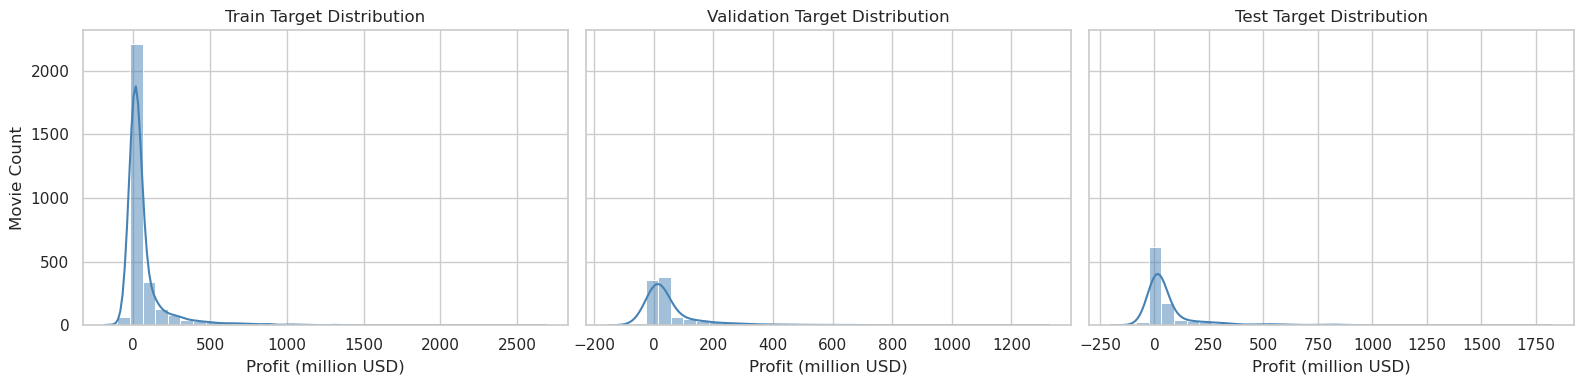

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, values, title in zip(
    axes,
    [y_train, y_val, y_test],
    ["Train Target Distribution", "Validation Target Distribution", "Test Target Distribution"],
):
    sns.histplot(values / 1_000_000, bins=35, kde=True, ax=ax, color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Profit (million USD)")
    ax.set_ylabel("Movie Count")
plt.tight_layout()
plt.show()

In [28]:
def regression_metrics(y_true, y_pred) -> dict[str, float]:
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


def evaluate_model(name: str, model, X_train_eval, X_val_eval, X_test_eval) -> dict[str, float]:
    rows = {}
    for split_name, X_split, y_split in [
        ("Train", X_train_eval, y_train),
        ("Val", X_val_eval, y_val),
        ("Test", X_test_eval, y_test),
    ]:
        predictions = model.predict(X_split)
        metrics = regression_metrics(y_split, predictions)
        rows[f"{split_name} R2"] = metrics["R2"]
        rows[f"{split_name} RMSE"] = metrics["RMSE"]
        rows[f"{split_name} MAE"] = metrics["MAE"]
    rows["Model"] = name
    return rows


def format_usd(value: float) -> str:
    return f"${value:,.0f}"


def display_metrics(metrics: dict[str, float], splits=("Train", "Val")) -> pd.DataFrame:
    records = []
    for split in splits:
        records.append({
            "Split": split,
            "R2": f"{metrics[f'{split} R2']:.3f}",
            "RMSE (USD)": format_usd(metrics[f"{split} RMSE"]),
            "MAE (USD)": format_usd(metrics[f"{split} MAE"]),
        })
    return pd.DataFrame(records)


model_results = []

# 4. Baseline Model

The baseline model is a simple linear regression using only `budget`, the strongest profit-related signal found in P1. This model sets the minimum performance level that later models should improve on.

In [29]:
baseline_features = ["budget"]
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])
baseline_model.fit(X_train[baseline_features], y_train)
baseline_metrics = evaluate_model(
    "Baseline (simple LR)",
    baseline_model,
    X_train[baseline_features],
    X_val[baseline_features],
    X_test[baseline_features],
)
model_results.append(baseline_metrics)
display(display_metrics(baseline_metrics))


,Split,R2,RMSE (USD),MAE (USD)
0,Train,0.417,"$133,866,675","$66,358,184"
1,Val,0.328,"$115,155,671","$62,873,803"


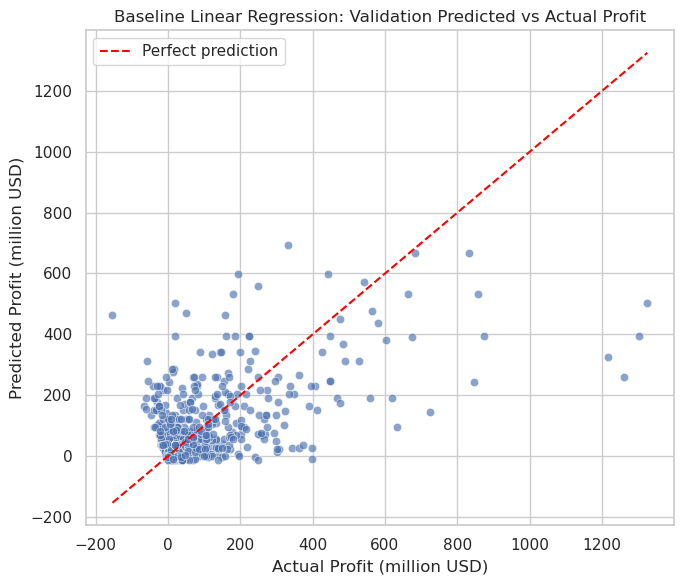

In [30]:
baseline_val_pred = baseline_model.predict(X_val[baseline_features])

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_val / 1_000_000, y=baseline_val_pred / 1_000_000, alpha=0.65)
min_val = min(y_val.min(), baseline_val_pred.min()) / 1_000_000
max_val = max(y_val.max(), baseline_val_pred.max()) / 1_000_000
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect prediction")
plt.title("Baseline Linear Regression: Validation Predicted vs Actual Profit")
plt.xlabel("Actual Profit (million USD)")
plt.ylabel("Predicted Profit (million USD)")
plt.legend()
plt.tight_layout()
plt.show()

# 5. Multiple Linear Regression

The multiple linear regression model uses all selected numeric, engineered, binned, and genre-encoded features. Coefficients are interpreted after scaling, so larger absolute values indicate stronger model influence on the same standardized scale.

In [31]:
multiple_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])
multiple_lr.fit(X_train, y_train)
multiple_lr_metrics = evaluate_model("Multiple LR", multiple_lr, X_train, X_val, X_test)
model_results.append(multiple_lr_metrics)
display(display_metrics(multiple_lr_metrics))


,Split,R2,RMSE (USD),MAE (USD)
0,Train,0.535,"$119,575,563","$61,052,343"
1,Val,0.438,"$105,293,072","$59,697,801"


In [32]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": multiple_lr.named_steps["model"].coef_,
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

positive_coef = coef_df.sort_values("coefficient", ascending=False).head(8).copy()
positive_coef["coefficient"] = positive_coef["coefficient"].map(format_usd)
positive_coef["abs_coefficient"] = positive_coef["abs_coefficient"].map(format_usd)

negative_coef = coef_df.sort_values("coefficient", ascending=True).head(8).copy()
negative_coef["coefficient"] = negative_coef["coefficient"].map(format_usd)
negative_coef["abs_coefficient"] = negative_coef["abs_coefficient"].map(format_usd)

print("Largest positive coefficients:")
display(positive_coef)

print("Largest negative coefficients:")
display(negative_coef)

Largest positive coefficients:


,feature,coefficient,abs_coefficient
7,budget_x_votes,"$573,341,227","$573,341,227"
8,rating_x_votes,"$328,594,611","$328,594,611"
0,budget,"$77,590,361","$77,590,361"
5,rank,"$29,882,914","$29,882,914"
17,genre_adventure,"$9,030,543","$9,030,543"
19,genre_romance,"$4,010,660","$4,010,660"
4,runtimeMinutes,"$2,627,224","$2,627,224"
9,runtime_group_short,"$1,280,218","$1,280,218"


Largest negative coefficients:


,feature,coefficient,abs_coefficient
2,log_numVotes,"$-501,933,110","$501,933,110"
1,log_budget,"$-372,904,271","$372,904,271"
3,averageRating,"$-158,261,442","$158,261,442"
13,genre_drama,"$-13,377,685","$13,377,685"
16,genre_crime,"$-6,047,259","$6,047,259"
15,genre_action,"$-5,979,232","$5,979,232"
23,genre_sci_fi,"$-4,763,423","$4,763,423"
18,genre_thriller,"$-3,647,224","$3,647,224"


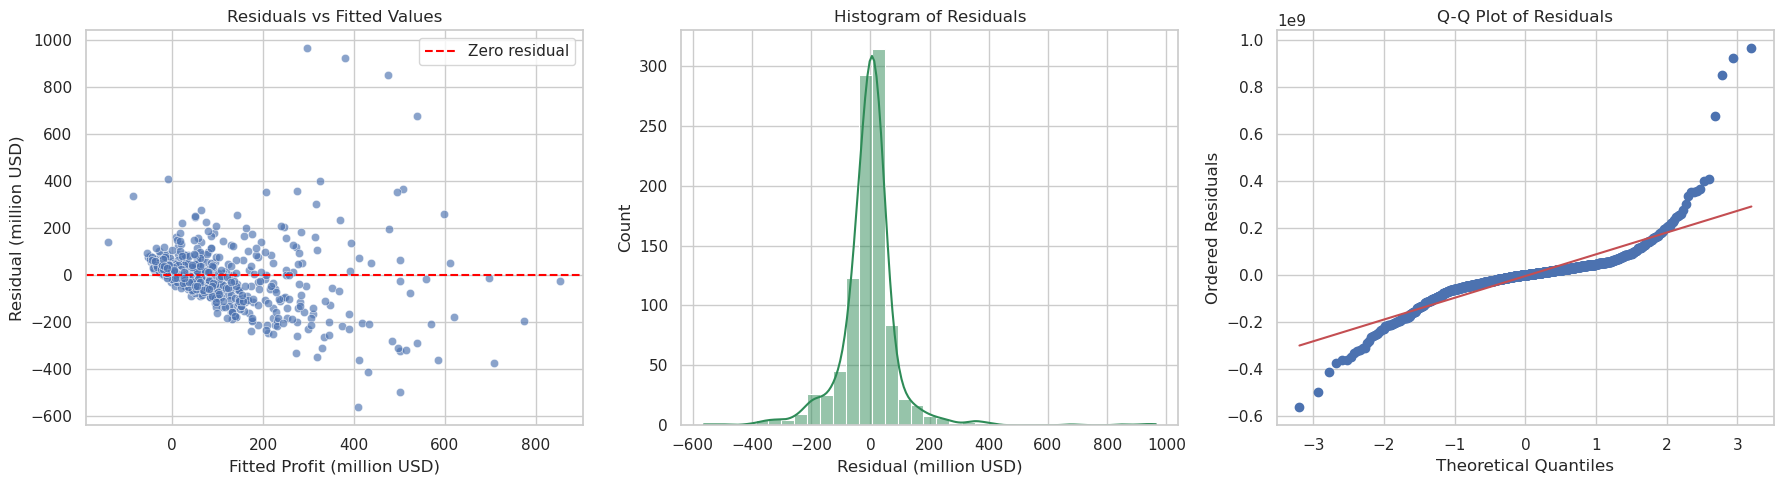

In [33]:
multiple_val_pred = multiple_lr.predict(X_val)
multiple_residuals = y_val - multiple_val_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=multiple_val_pred / 1_000_000, y=multiple_residuals / 1_000_000, alpha=0.65, ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--", label="Zero residual")
axes[0].set_title("Residuals vs Fitted Values")
axes[0].set_xlabel("Fitted Profit (million USD)")
axes[0].set_ylabel("Residual (million USD)")
axes[0].legend()

sns.histplot(multiple_residuals / 1_000_000, bins=35, kde=True, color="seagreen", ax=axes[1])
axes[1].set_title("Histogram of Residuals")
axes[1].set_xlabel("Residual (million USD)")
axes[1].set_ylabel("Count")

stats.probplot(multiple_residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot of Residuals")
axes[2].set_xlabel("Theoretical Quantiles")
axes[2].set_ylabel("Ordered Residuals")

plt.tight_layout()
plt.show()

The coefficient table suggests that budget/vote scale and the interaction terms are the largest drivers in the linear model, which matches the idea that high-budget movies with broad audience attention are more likely to earn large profits. Some individual coefficient signs should be interpreted cautiously: the model includes raw, log-transformed, and interaction versions of related variables, so multicollinearity can produce counterintuitive opposing signs such as positive `budget` but negative `log_budget`.

The residual plots show that the model captures the broad profit trend but still struggles with extreme blockbuster profits and large losses. The residual histogram and Q-Q plot are not perfectly normal, which is expected because movie profits are highly skewed.

# 6. Polynomial Regression

Polynomial regression is tested with degrees 1, 2, and 3. This model intentionally uses a numeric subset instead of all 24 multiple-regression features. Expanding all genre and runtime dummy variables would create many sparse interaction terms, so this section tests nonlinear numeric relationships rather than acting as a direct extension of the full multiple linear model.

In [34]:
poly_features = [
    "budget",
    "log_budget",
    "log_numVotes",
    "averageRating",
    "runtimeMinutes",
    "rank",
    "movie_age",
]

poly_results = []
poly_models = {}
for degree in [1, 2, 3]:
    poly_model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])
    poly_model.fit(X_train[poly_features], y_train)
    metrics = evaluate_model(
        f"Polynomial (degree {degree})",
        poly_model,
        X_train[poly_features],
        X_val[poly_features],
        X_test[poly_features],
    )
    metrics["degree"] = degree
    poly_results.append(metrics)
    poly_models[degree] = poly_model

poly_table = pd.DataFrame(poly_results)
poly_display = poly_table[["degree", "Train R2", "Val R2", "Train RMSE", "Val RMSE", "Test R2", "Test RMSE"]].copy()
for col in ["Train R2", "Val R2", "Test R2"]:
    poly_display[col] = poly_display[col].map(lambda value: f"{value:.3f}")
for col in ["Train RMSE", "Val RMSE", "Test RMSE"]:
    poly_display[col] = poly_display[col].map(format_usd)
display(poly_display)


,degree,Train R2,Val R2,Train RMSE,Val RMSE,Test R2,Test RMSE
0,1,0.489,0.412,"$125,321,412","$107,719,073",0.480,"$113,904,084"
1,2,0.612,0.449,"$109,237,044","$104,218,559",0.523,"$109,136,532"
2,3,0.697,0.409,"$96,492,137","$107,944,466",0.529,"$108,439,969"


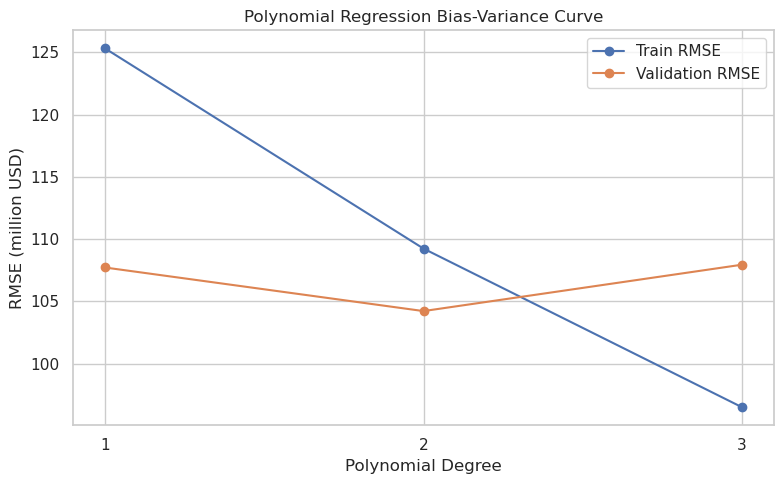

Best polynomial degree by validation RMSE: 2


In [35]:
plt.figure(figsize=(8, 5))
plt.plot(poly_table["degree"], poly_table["Train RMSE"] / 1_000_000, marker="o", label="Train RMSE")
plt.plot(poly_table["degree"], poly_table["Val RMSE"] / 1_000_000, marker="o", label="Validation RMSE")
plt.title("Polynomial Regression Bias-Variance Curve")
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE (million USD)")
plt.xticks([1, 2, 3])
plt.legend()
plt.tight_layout()
plt.show()

best_poly_row = poly_table.sort_values(["Val RMSE", "Val R2"], ascending=[True, False]).iloc[0]
best_poly_degree = int(best_poly_row["degree"])
best_poly_model = poly_models[best_poly_degree]
model_results.append({k: v for k, v in best_poly_row.items() if k != "degree"} | {"Model": f"Polynomial (best degree {best_poly_degree})"})
print(f"Best polynomial degree by validation RMSE: {best_poly_degree}")

The bias-variance curve shows clear overfitting at degree 3. Degree 2 has the best validation RMSE at about **$104.2M**, while degree 3 lowers training RMSE further but worsens validation RMSE to about **$107.9M**. Therefore, degree 2 is selected as the best polynomial model because it captures useful curvature without the extra overfitting seen in degree 3.

# 7. Regularization

Ridge regression applies L2 regularization, which shrinks coefficients while keeping all features. Lasso regression applies L1 regularization, which can shrink some coefficients exactly to zero and therefore performs feature selection.

In [36]:
alphas = np.logspace(-2, 8, 60)

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=alphas)),
])
ridge_model.fit(X_train, y_train)
ridge_metrics = evaluate_model("Ridge", ridge_model, X_train, X_val, X_test)
model_results.append(ridge_metrics)
print(f"Selected Ridge alpha: {ridge_model.named_steps['model'].alpha_:,.4f}")
display(display_metrics(ridge_metrics))


Selected Ridge alpha: 0.1536


,Split,R2,RMSE (USD),MAE (USD)
0,Train,0.535,"$119,583,300","$60,985,169"
1,Val,0.439,"$105,184,009","$59,585,306"


In [37]:
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LassoCV(
        # profit is in USD hundreds-of-millions, so alphas below ~1000 have no regularizing effect
        alphas=np.logspace(3, 8, 60),
        cv=5,
        random_state=RANDOM_STATE,
        max_iter=100_000,
    )),
])
lasso_model.fit(X_train, y_train)
lasso_metrics = evaluate_model("Lasso", lasso_model, X_train, X_val, X_test)
model_results.append(lasso_metrics)
print(f"Selected Lasso alpha: {lasso_model.named_steps['model'].alpha_:,.4f}")
display(display_metrics(lasso_metrics))

Selected Lasso alpha: 5,790.4440


,Split,R2,RMSE (USD),MAE (USD)
0,Train,0.535,"$119,576,114","$61,028,115"
1,Val,0.438,"$105,254,704","$59,661,246"


In [38]:
lasso_coef = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lasso_model.named_steps["model"].coef_,
})
# Lasso coefficients are rarely exactly 0.0 in floating point; isclose catches near-zero values
lasso_coef["zeroed_out"] = np.isclose(lasso_coef["coefficient"], 0.0)
zeroed_features = lasso_coef.loc[lasso_coef["zeroed_out"], "feature"].tolist()

print(f"Number of Lasso-zeroed features: {len(zeroed_features)}")
if zeroed_features:
    display(pd.DataFrame({"zeroed_feature": zeroed_features}))
else:
    print("No features were zeroed out by the selected alpha.")

lasso_top = lasso_coef.sort_values("coefficient", key=lambda s: s.abs(), ascending=False).head(12).copy()
lasso_top["coefficient"] = lasso_top["coefficient"].map(format_usd)
display(lasso_top)

Number of Lasso-zeroed features: 1


,zeroed_feature
0,runtime_group_standard


,feature,coefficient,zeroed_out
7,budget_x_votes,"$567,003,405",False
2,log_numVotes,"$-495,701,094",False
1,log_budget,"$-368,968,502",False
8,rating_x_votes,"$324,682,620",False
3,averageRating,"$-155,973,657",False
0,budget,"$77,806,260",False
5,rank,"$29,829,291",False
13,genre_drama,"$-13,351,385",False
17,genre_adventure,"$9,027,016",False
16,genre_crime,"$-6,022,736",False


Lasso zeroed out only `runtime_group_standard`. This result makes sense because standard-length films are the most ordinary runtime category, and that dummy adds little unique signal after the model already includes raw `runtimeMinutes`, budget, vote, rating, genre, and interaction features. The retained features indicate that Lasso still found useful signal in the financial scale, audience attention, and genre-related predictors.

# 8. Model Comparison

The table below summarizes all required models. The best model is selected using validation RMSE as the primary criterion because it measures prediction error in the same USD units as the target.

In [39]:
comparison = pd.DataFrame(model_results)
comparison = comparison[[
    "Model", "Train R2", "Val R2", "Test R2", "Test RMSE", "Test MAE", "Val RMSE", "Val MAE"
]].copy()
comparison_display = comparison[["Model", "Train R2", "Val R2", "Test R2", "Test RMSE", "Test MAE"]].copy()
for col in ["Train R2", "Val R2", "Test R2"]:
    comparison_display[col] = comparison_display[col].map(lambda value: f"{value:.3f}")
for col in ["Test RMSE", "Test MAE"]:
    comparison_display[col] = comparison_display[col].map(format_usd)
display(comparison_display)


,Model,Train R2,Val R2,Test R2,Test RMSE,Test MAE
0,Baseline (simple LR),0.417,0.328,0.410,"$121,325,173","$66,084,332"
1,Multiple LR,0.535,0.438,0.530,"$108,313,021","$61,439,538"
2,Polynomial (best degree 2),0.612,0.449,0.523,"$109,136,532","$58,087,036"
3,Ridge,0.535,0.439,0.530,"$108,315,698","$61,373,342"
4,Lasso,0.535,0.438,0.530,"$108,303,767","$61,409,447"


In [40]:
best_model_row = comparison.sort_values(["Val RMSE", "Val R2"], ascending=[True, False]).iloc[0]
print("Best model by validation RMSE:", best_model_row["Model"])
print(f"Final test R2: {best_model_row['Test R2']:.3f}")
print(f"Final test RMSE: ${best_model_row['Test RMSE']:,.0f}")
print(f"Final test MAE: ${best_model_row['Test MAE']:,.0f}")

Best model by validation RMSE: Polynomial (best degree 2)
Final test R2: 0.523
Final test RMSE: $109,136,532
Final test MAE: $58,087,036


The selected model is the one with the lowest validation RMSE. This criterion favors the model that makes the smallest validation-set prediction errors in dollars, while the final test metrics above provide the held-out estimate of generalization performance.

# 9. Interpretation & Reflection

The regression results show that movie profit is partly predictable from budget, audience attention, rating, runtime, age, and genre. Budget is a strong baseline signal, and engineered vote/budget interactions improve the model because high-budget movies with large audience attention are more likely to become high-profit blockbusters.

The predictions are useful for broad trend-level analysis, but they are not precise enough for exact financial forecasting. Even the stronger models still have large RMSE and MAE values because the target is measured in dollars and includes extreme blockbuster outliers. A few movies earn unusually high profits, and ordinary linear models struggle to predict those rare outcomes exactly.

The main sources of error are financial outliers, missing business variables, and target uncertainty from TMDB matching and financial imputation. Important predictors such as marketing spend, release scale, franchise status, international distribution, streaming revenue, and competition at release are not available in this dataset. `numVotes` is also a post-release audience signal, so it helps prediction but would not be available for true pre-release forecasting.

For P3, these findings suggest that classification tasks may be more stable than exact profit regression. Instead of predicting exact profit in dollars, P3 can use engineered genre, budget, rating, runtime, and popularity features to classify movie quality or popularity groups, where outliers may have less damaging influence.